# Beyond p < 0.05


* Author: Philippe Monnot
* Date: 10/03/26

# Setup
---

## Imports

In [1]:
from __future__ import annotations

In [2]:
import logging
import warnings
from dataclasses import dataclass
from pathlib import Path

In [3]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import seaborn as sns
from preliz import Beta
from scipy import stats

In [4]:
from zpa_demo.types import SimulationResult
from zpa_demo.utils import configure_logging
from zpa_demo.visualisation import (
    plot_conversion_rates,
    plot_p_value_histogram,
    plot_simulation_results,
)

In [5]:
import jupyter_black

jupyter_black.load()

## Extensions

In [6]:
%load_ext IPython.extensions.autoreload
%autoreload 2

In [7]:
%load_ext watermark
%watermark -u -n -t
%watermark -iv -v -m

Last updated: Tue, 10 Mar 2026 13:17:25

Python implementation: CPython
Python version       : 3.12.10
IPython version      : 9.10.0

Compiler    : Clang 13.0.0 (clang-1300.0.29.30)
OS          : Darwin
Release     : 24.6.0
Machine     : arm64
Processor   : arm
CPU cores   : 12
Architecture: 64bit

arviz        : 0.23.4
jupyter_black: 0.4.0
logging      : 0.5.1.2
matplotlib   : 3.10.8
numpy        : 2.4.2
pandas       : 3.0.1
preliz       : 0.24.0
pymc         : 5.28.1
scipy        : 1.17.1
seaborn      : 0.13.2
zpa_demo     : 0.1.0



## Configuration

In [8]:
warnings.simplefilter(action="ignore", category=FutureWarning)

In [9]:
configure_logging(debug=False)
logger = logging.getLogger(__name__)
logger.info("Notebook logger configured.")

INFO | 2026-03-10 13:17:25,743 | __main__ | Notebook logger configured.


## Constants

In [10]:
OUTPUT_DIR: Path = Path("../results/")

DEFAULT_RANDOM_SEED: int = 42
DEFAULT_LIFT: float = 0.00
DEFAULT_SIGNIFICANCE_LEVEL: float = 0.05
DEFAULT_N_SAMPLES: int = 10_000

# Main
---

## Part 1 - Gaining practical intuition behind the p-value

We've just seen that a p-value is about **data under the null hypothesis**, not the truth about the parameter we're trying to estimate. That's abstract still ... let's make it concrete.

**The setup:** In Zorro, we're testing whether a new feature that improves conversion. We know the ground truth: the feature has **no impact** on conversion (effect/lift = 0). 

Now let's run 10,000 A/B tests and watch what happens. Think of it as creating 10,000 parallel universes where the null hypothesis is true.

In [11]:
@dataclass
class SimulatedData:
    """Container that holds simulated data for A/B testing.

    Args:
        n_samples: Number of samples per group.
        baseline_rate: Conversion rate for the control group.
        lift: Relative lift applied to the treatment group (e.g. 0.1 = +10%).
        treated: Binary array of conversion outcomes for the treatment group.
        control: Binary array of conversion outcomes for the control group.
    """

    n_samples: int
    baseline_rate: float
    lift: float
    treated: np.ndarray
    control: np.ndarray

    @property
    def observed_effect(self) -> float:
        """Calculate the observed treatment effect (difference in conversion rates)."""
        return self.treated.mean() - self.control.mean()

    def to_dataframe(self) -> pd.DataFrame:
        """Convert the simulated data to a pandas DataFrame."""
        return pd.DataFrame(
            {
                "group": ["control"] * self.n_samples + ["treated"] * self.n_samples,
                "converted": np.concatenate([self.control, self.treated]),
            }
        )

    def plot(self) -> None:
        """Plot the conversion rates for control and treatment groups."""
        plot_conversion_rates(df=self.to_dataframe())

We model A/B test conversions with a Binomial distribution, where each user either converts or doesn't, with some probability `p`. 

The simulator below draws `n` samples (clicks/conversions/users) per group.

In [12]:
@dataclass
class ConversionRateSimulator:
    """Class that simulates conversion rates for A/B testing using a Binomial data generating process.

    Args:
        baseline_rate: Conversion rate for the control group.
        seed: Random seed for reproducibility.
    """

    baseline_rate: float
    seed: int = DEFAULT_RANDOM_SEED

    def __post_init__(self):
        assert (
            0.0 <= self.baseline_rate <= 1.0
        ), "Baseline rate must be between 0 and 1."
        self.rng = np.random.default_rng(self.seed)

    def simulate(self, n_samples: int, lift: float) -> SimulatedData:
        """Simulate conversions for control and treatment groups.

        Args:
            n_samples: Number of samples per group.
            lift: Absolute lift to apply to the treatment group (e.g. 0.1 = +10%)

        Returns:
            SimulatedData object containing the results of the simulation.
        """
        assert n_samples > 0, "Number of samples must be positive."
        assert lift >= -1.0, "Lift must be greater than or equal to -100%."
        return self._simulate(n_samples=n_samples, lift=lift)

    def _simulate(self, n_samples: int, lift: float) -> SimulatedData:
        """Internal method to perform the actual simulation.

        Args:
            n_samples: Number of samples per group.
            lift: Absolute lift to apply to the treatment group.

        Returns:
            SimulatedData object containing the results of the simulation.
        """
        control = self._dgp(n_samples=n_samples, treated=False)
        treated = self._dgp(n_samples=n_samples, treated=True, lift=lift)
        return SimulatedData(
            n_samples=n_samples,
            baseline_rate=self.baseline_rate,
            lift=lift,
            treated=treated,
            control=control,
        )

    def _dgp(
        self, n_samples: int, lift: float = 0.0, treated: bool = False
    ) -> np.ndarray:
        """Data generating process for a single group under a Binomial model.

        Args:
            n_samples: Number of samples to generate.
            lift: Absolute lift to apply if treated.
            treated: If True, applies the absolute lift to the conversion rate.

        Returns:
            Binary array of conversion outcomes.
        """
        rate = (self.baseline_rate + lift) if treated else self.baseline_rate
        rate = np.clip(rate, 0.0, 1.0)  # ensure conversion rate is between 0 and 1
        return self.rng.binomial(n=1, p=rate, size=n_samples)

We use the chi-squared test to calculate a p-value.

In [13]:
@dataclass
class TestResult:
    """Result of a statistical test on A/B data."""

    test_name: str
    statistic_name: str
    statistic: float
    p_value: float
    alpha: float = DEFAULT_SIGNIFICANCE_LEVEL

    def __repr__(self) -> str:
        return (
            f"{self.test_name} test: {self.statistic_name} = {self.statistic:.4f}, "
            f"p-value = {self.p_value:.4g}, "
            f"alpha = {self.alpha:.2f}, significant = {self.p_value < self.alpha}"
        )

In [14]:
def chi2_test(
    data: SimulatedData, alpha: float = DEFAULT_SIGNIFICANCE_LEVEL
) -> TestResult:
    """Pearson chi2 test on a 2x2 contingency table.

                    Treated | Control
                    -----------------
    Converted       | a     | b
    Not Converted   | c     | d

    Args:
        data: Simulated A/B data.
        alpha: Significance level for hypothesis testing.

    Returns:
        TestResult with chi2 statistic and p-value.
    """
    contingency = np.array(
        [
            [data.treated.sum(), data.control.sum()],
            [data.n_samples - data.treated.sum(), data.n_samples - data.control.sum()],
        ]
    )
    chi2_stat, p_val, _, _ = stats.chi2_contingency(contingency)
    return TestResult(
        test_name="chi2",
        statistic_name="chi2",
        statistic=float(chi2_stat),  # type: ignore
        p_value=float(p_val),  # type: ignore
        alpha=alpha,
    )

Let's instanciate our A/B test synthetic data generator.

Simulating A/B test data with no lift (lift=0.00%) and sample size 10000 per group.
SimulatedData(n_samples=10000, baseline_rate=0.4, lift=0.0, treated=array([1, 1, 0, ..., 1, 1, 0], shape=(10000,)), control=array([1, 0, 1, ..., 0, 0, 0], shape=(10000,)))


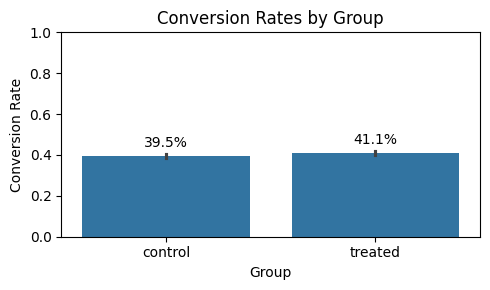

In [15]:
no_lift = DEFAULT_LIFT
sample_size = DEFAULT_N_SAMPLES
print(
    f"Simulating A/B test data with no lift (lift={no_lift:.2%}) and sample size {sample_size} per group."
)
sim = ConversionRateSimulator(baseline_rate=0.4)
simulated_data = sim.simulate(n_samples=sample_size, lift=no_lift)
print(simulated_data)
simulated_data.plot()

Let's compute the p-value from the chi-squared test at our chosen significance level.

In [16]:
alpha = DEFAULT_SIGNIFICANCE_LEVEL
print(chi2_test(simulated_data, alpha=alpha))

chi2 test: chi2 = 5.0573, p-value = 0.02452, alpha = 0.05, significant = True


Time to run the experiment ...

In [17]:
N_EXPERIMENTS: int = 10_000

In [18]:
p_values: np.ndarray = np.empty(N_EXPERIMENTS)
observed_effects: np.ndarray = np.empty(N_EXPERIMENTS)
for i in range(N_EXPERIMENTS):
    simulated_data = sim.simulate(n_samples=sample_size, lift=no_lift)
    test_result = chi2_test(simulated_data)
    p_values[i] = test_result.p_value
    observed_effects[i] = simulated_data.observed_effect

results = SimulationResult(p_values=p_values, observed_effects=observed_effects)

In [19]:
print(results)

SimulationResult(p_values=array([0.81772115, 0.79503302, 0.55449836, ..., 0.26572736, 0.98846929,
       0.82829813], shape=(10000,)), observed_effects=array([-0.0017,  0.0019,  0.0042, ..., -0.0078, -0.0002,  0.0016],
      shape=(10000,)))


Below we plot the distribution fo observed efffect sizes and p-values across our 10,000 experiments. Don't forget that the true effect is zero in every single one of these experiments.

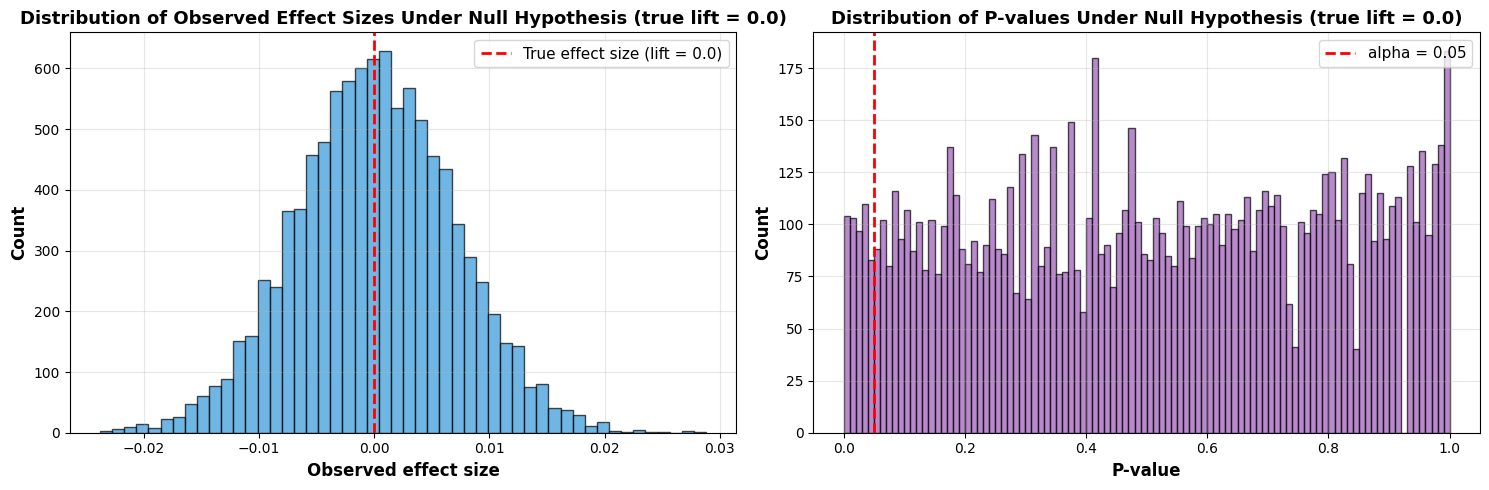

In [20]:
plot_simulation_results(results=results, lift=no_lift, alpha=alpha)

Observations:
* The observed effects scatter symmetrically around zero, which is **exactly what we'd expect** when there's no real difference.
* The p-values are approximately uniformly distributed between 0 and 1 under the null hypothesis.


Another quiz ... Out of the 10,000 experiments with no real effect, how many produced p < 0.05?

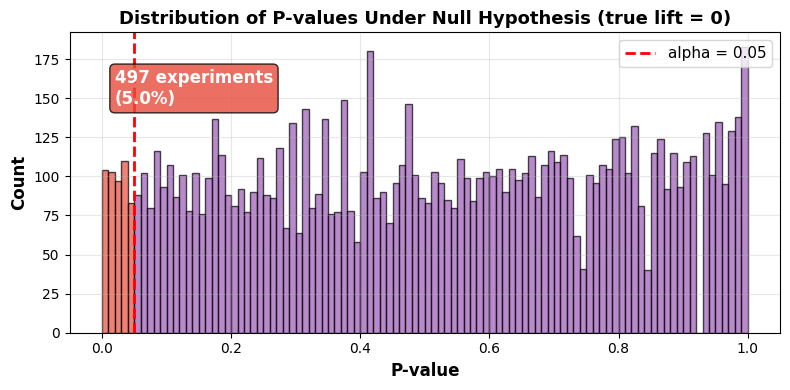

In [23]:
plot_p_value_histogram(results, alpha=alpha)

**Observations**

* **This is expected behavior, not a bug.**

* Under the null, about **5% of p-values fall below 0.05 purely by chance**.

* Those are **false positives**: statistically significant results with no true effect.

* This is exactly what **alpha = 0.05** means in practice.

* So a p-value measures **compatibility with the null**, not proof that an effect is real.

## Part 2 - Making it real

So under the null, p-values are uniform and ~5% are false alarms. That's the definition of α = 0.05.

**But what happens when the effect is not-null/real?** How are the p-values distributed?

Let's compare both scenarios.

In [33]:
N_EXPERIMENTS: int = 10_000
SAMPLE_SIZE: int = 10_000  # 10_000

In [25]:
p_values = np.empty(N_EXPERIMENTS)
observed_effects = np.empty(N_EXPERIMENTS)
for i in range(N_EXPERIMENTS):
    simulated_data = sim.simulate(n_samples=SAMPLE_SIZE, lift=no_lift)
    test_result = chi2_test(simulated_data)
    p_values[i] = test_result.p_value
    observed_effects[i] = simulated_data.observed_effect

null_results = SimulationResult(p_values=p_values, observed_effects=observed_effects)

First, the null world again. No effect, just random noise. The histogram should look familiar: uniform p-values, with ~5% falling below α.

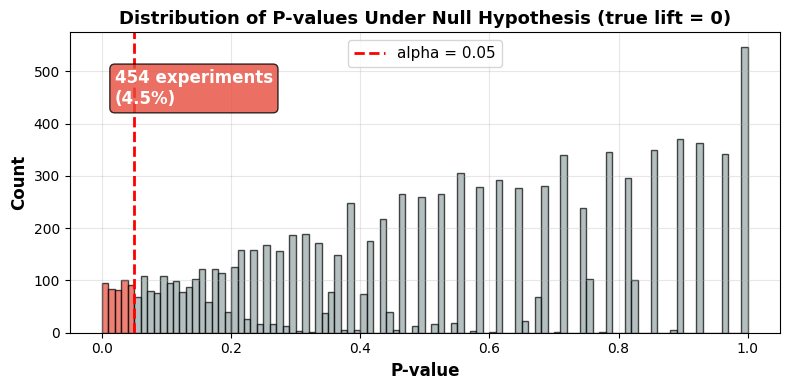

In [26]:
plot_p_value_histogram(null_results, alpha=alpha, base_color="#95a5a6")

Second, let's apply a non-zero lift.

In [34]:
TRUE_LIFT: float = 0.01  # 0.01

In [35]:
p_values = np.empty(N_EXPERIMENTS)
observed_effects = np.empty(N_EXPERIMENTS)
for i in range(N_EXPERIMENTS):
    simulated_data = sim.simulate(n_samples=SAMPLE_SIZE, lift=TRUE_LIFT)
    test_result = chi2_test(simulated_data)
    p_values[i] = test_result.p_value
    observed_effects[i] = simulated_data.observed_effect

lift_results = SimulationResult(p_values=p_values, observed_effects=observed_effects)

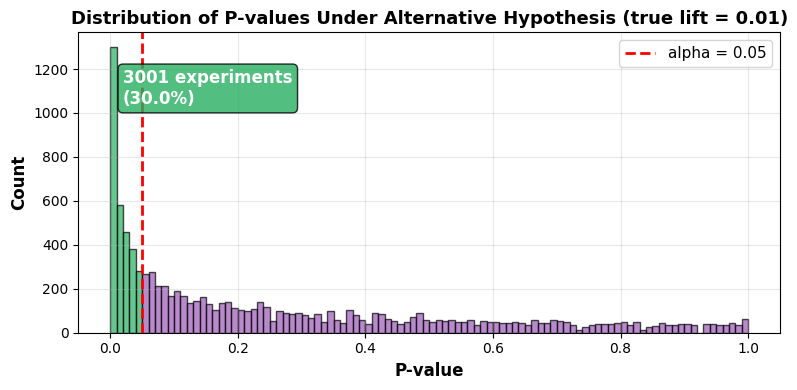

In [36]:
plot_p_value_histogram(
    lift_results,
    alpha=alpha,
    title=f"Distribution of P-values Under Alternative Hypothesis (true lift = {TRUE_LIFT})",
    below_alpha_color="#27ae60",
)

**Observations**

* Even when a real effect exists, p-values still vary from experiment to experiment because of random sampling variation.

* Under the alternative hypothesis, the p-value distribution shifts toward 0, so small p-values become much more common.

* The proportion of experiments with **(p < 0.05)** is the **statistical power** of the test: the probability of detecting a real effect.

* In this simulation, power is about **60%**, meaning we correctly detect the true effect in roughly **6 out of 10 experiments**.

* The remaining **39.8%** are **false negatives**: cases where a real effect exists, but the test does not reach significance.

In [ ]:
power = (lift_results.p_values < alpha).mean() * 100
print(
    f"Power of the test to detect a lift of {TRUE_LIFT:.2%} at alpha = {alpha:.2f}: {power:.1f}%"
)

## Part 3 - Statistical significance vs practical significance

Let's imagine another scenario. We run Zorro's A/B test, but with 1 million users.

The dashboard shows that `p = 0.001 < α (0.05)`. *Highly significant!*

But the actual conversion rates are:

| Group | Conversion Rate |
|-------|----------------|
| Control | 40.0% |
| Treatment | 40.5% |

An absolute lift of **0.5 pp**. In practical terms, it's equivalent to a user who converts 400 times instead of 405 out of 1,000 visits.

Let's simulate it!

In [37]:
TRUE_LIFT: float = 0.005  # 0.5% lift
SAMPLE_SIZE = 1_000_000

In [38]:
simulated_data = sim.simulate(n_samples=SAMPLE_SIZE, lift=TRUE_LIFT)
print(chi2_test(simulated_data))
print(f"Observed effect size: {simulated_data.observed_effect:.4%}")

chi2 test: chi2 = 55.8745, p-value = 7.725e-14, alpha = 0.05, significant = True
Observed effect size: 0.5186%


The test is significant, but the effect size is tiny ...

The p-value is telling us that *"given 1,000,000 observations, this difference is unlikely to be random."*.

It's **not** telling us that *"this difference is worth shipping."*

> **Statistical significance** = we're confident *something* is happening

> **Practical significance** = what's happening is *large enough to act on*

These are entirely different questions. With N = 1,000,000, the first is almost always answered "yes" — which makes it nearly useless. 

The second question is what actually matters for the business. <<<

Let's run this experiment 100 times to see just how reliable or not this significance is.

In [39]:
N_EXPERIMENTS: int = 100

In [40]:
p_values = np.empty(N_EXPERIMENTS)
observed_effects = np.empty(N_EXPERIMENTS)
for i in range(N_EXPERIMENTS):
    simulated_data = sim.simulate(n_samples=SAMPLE_SIZE, lift=TRUE_LIFT)
    test_result = chi2_test(simulated_data)
    p_values[i] = test_result.p_value
    observed_effects[i] = simulated_data.observed_effect

lift_results = SimulationResult(p_values=p_values, observed_effects=observed_effects)

The scatter plot below shows the observed effect from each of the 100 experiments, with its 95% confidence interval. The red dashed line is the **true absolute effect**.

Across 100 experiments:
  All p-values significant? True
  Mean p-value: 0.000000
  Mean observed effect: 0.5042%



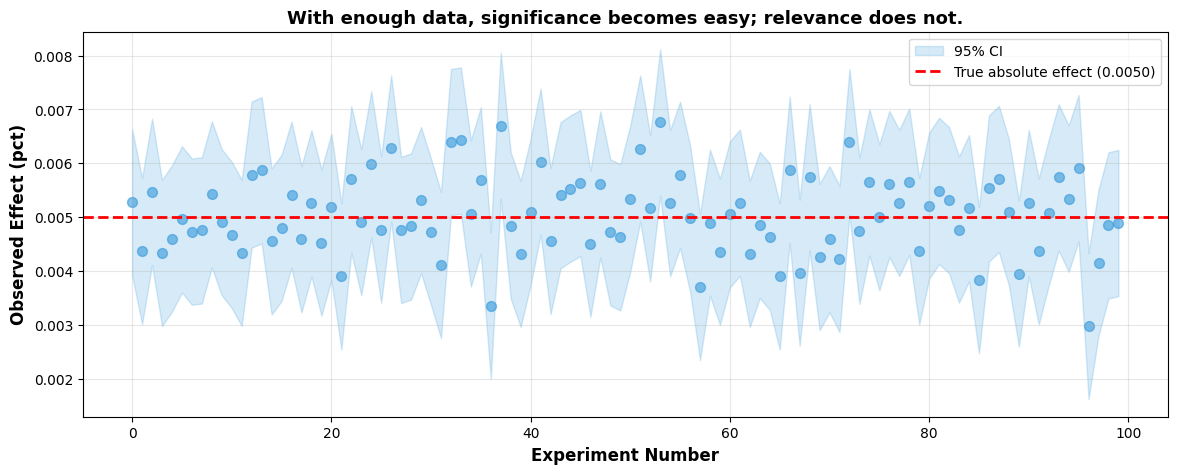

In [41]:
fig, ax = plt.subplots(1, 1, figsize=(14, 5))

ax.scatter(
    range(len(lift_results.observed_effects)),
    lift_results.observed_effects,
    alpha=0.6,
    s=50,
    color="#3498db",
)

se = np.sqrt((sim.baseline_rate * (1 - sim.baseline_rate) / SAMPLE_SIZE) * 2)
ci_margin = 1.96 * se
ax.fill_between(
    range(len(lift_results.observed_effects)),
    lift_results.observed_effects - ci_margin,
    lift_results.observed_effects + ci_margin,
    alpha=0.2,
    color="#3498db",
    label="95% CI",
)
ax.axhline(
    TRUE_LIFT,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"True absolute effect ({TRUE_LIFT:.4f})",
)
ax.set_ylabel("Observed Effect (pct)", fontsize=12, fontweight="bold")
ax.set_xlabel("Experiment Number", fontsize=12, fontweight="bold")
ax.set_title(
    "With enough data, significance becomes easy; relevance does not.",
    fontsize=13,
    fontweight="bold",
)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

print("Across 100 experiments:")
print(f"  All p-values significant? {(lift_results.p_values < 0.05).all()}")
print(f"  Mean p-value: {lift_results.p_values.mean():.6f}")
print(f"  Mean observed effect: {lift_results.observed_effects.mean() * 100:.4f}%")
print()

**Observations**

* At N = 1_000_000, the confidence intervals are extremely tight, so the effect estimate is very precise

* But the estimated effect is still **very small in absolute terms**: it stays close to zero throughout

* This highlights the difference between **statistical significance** and **practical significance**

* With enough data, even a **tiny and potentially unimportant effect** can be detected reliably

* In other words, the p-value is telling us the effect is **unlikely to be exactly zero**, not that it is **large or meaningful**

## Part 4 - What the p-value doesn't tell you, but you need to know

Here’s a cleaner and more precise version:

A p-value of **0.001** still leaves two critical questions unanswered:

* **How large is the effect?** → the **effect size**
* **How uncertain is that estimate?** → the **confidence interval**

This is where the **Bayesian framework** becomes especially useful. It lets us answer a more direct question:

> **Given the data and our model, what is the probability that the treatment effect is positive?**

Now let’s run the **exact same A/B test** through a Bayesian lens and compare what we learn.

### Let's generate some data

In [42]:
TRUE_LIFT: float = 0.02
SAMPLE_SIZE = 10_000

In [45]:
simulated_data = sim.simulate(n_samples=SAMPLE_SIZE, lift=TRUE_LIFT)
print(
    f"Simulated data with true lift of {TRUE_LIFT:.2%} and sample size {SAMPLE_SIZE} per group:"
)
print(chi2_test(simulated_data))
print(f"Observed effect size: {simulated_data.observed_effect:.4%}")

Simulated data with true lift of 2.00% and sample size 10000 per group:
chi2 test: chi2 = 10.3496, p-value = 0.001295, alpha = 0.05, significant = True
Observed effect size: 2.2500%


### The Bayesian Update

The fundamental idea in Bayesian statistics is that we can use data to update our beliefs.

* We start with a **prior distribution** that represents what we believe before we see the data,

* We compute a **posterior distribution** that represents what we believe after we see the data.

### Setting up the Bayesian model

We start by defining our conversion rate prior with a **Beta** distribution — a uniform distribution over [0, 1]. 

This says: before seeing any data, we consider all conversion rates equally plausible. It's deliberately uninformative so the data does the talking.

WARNING | 2026-03-10 13:28:29,589 | py.warnings | /Users/philippemonnot/Documents/repos/projects/zpa-demo-pvalues/.venv/lib/python3.12/site-packages/pytensor/link/numba/dispatch/basic.py:211: UserWarning: Numba will use object mode to run XlogY0's perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(



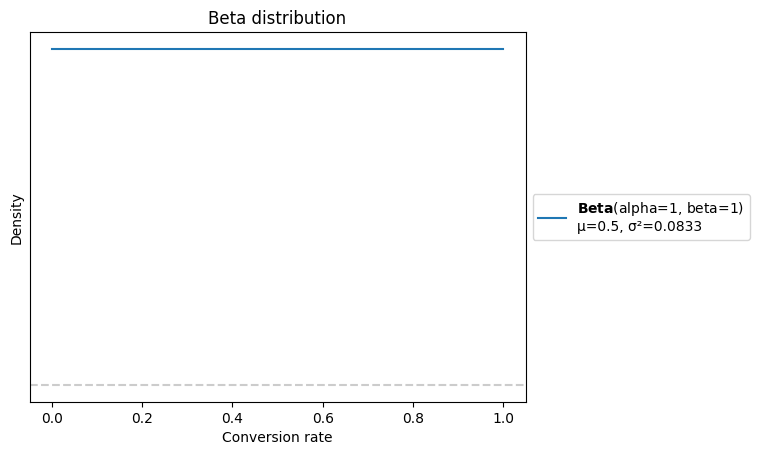

In [46]:
dist = Beta(1, 1)
dist.plot_pdf(moments="mv")
plt.xlabel("Conversion rate")
plt.ylabel("Density")
plt.title("Beta distribution");

Now we build the full model in PyMC. 

Each group gets its own Beta prior, and we observe binary conversions via a Binomial likelihood. 

The key quantity is `effect_size = p_treatment - p_control` — we get a full posterior distribution over this, not just a point estimate.

In [47]:
n: int = SAMPLE_SIZE
coords = {
    "samples": np.arange(n),
}

with pm.Model() as model:
    # define data containers for control and treatment conversions
    control_raw_obs = pm.Data("control_raw_obs", simulated_data.control, dims="samples")
    treatment_raw_obs = pm.Data(
        "treatment_raw_obs", simulated_data.treated, dims="samples"
    )

    # define weakly informed priors for conversion rates (p) in control and treatment groups
    p_control = pm.Beta("p_control", alpha=1, beta=1)
    p_treatment = pm.Beta("p_treatment", alpha=1, beta=1)

    # define likelihoods for observed conversions in control and treatment groups
    # we're using a Bernoulli likelihood here since we have individual binary outcomes per user
    control_conversions = pm.Bernoulli(
        "control_conversions", p=p_control, observed=control_raw_obs
    )
    treatment_conversions = pm.Bernoulli(
        "treatment_conversions", p=p_treatment, observed=treatment_raw_obs
    )

    effect_size = pm.Deterministic("effect_size", p_treatment - p_control)

    trace = pm.sample(
        2000,
        tune=1000,
        return_inferencedata=True,
        random_seed=DEFAULT_RANDOM_SEED,
        progressbar=True,
        cores=-1,
    )

Initializing NUTS using jitter+adapt_diag...


INFO | 2026-03-10 13:30:05,967 | pymc.sampling.mcmc | Initializing NUTS using jitter+adapt_diag...


Sequential sampling (2 chains in 1 job)


INFO | 2026-03-10 13:30:06,727 | pymc.sampling.mcmc | Sequential sampling (2 chains in 1 job)


NUTS: [p_control, p_treatment]


...

Output()

Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 2 seconds.


INFO | 2026-03-10 13:30:09,158 | pymc.sampling.mcmc | Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 2 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


INFO | 2026-03-10 13:30:09,346 | pymc.stats.convergence | We recommend running at least 4 chains for robust computation of convergence diagnostics


Let's plot the posterior mean.

array([<Axes: title={'center': 'p_control'}>,
       <Axes: title={'center': 'p_treatment'}>,
       <Axes: title={'center': 'effect_size'}>], dtype=object)

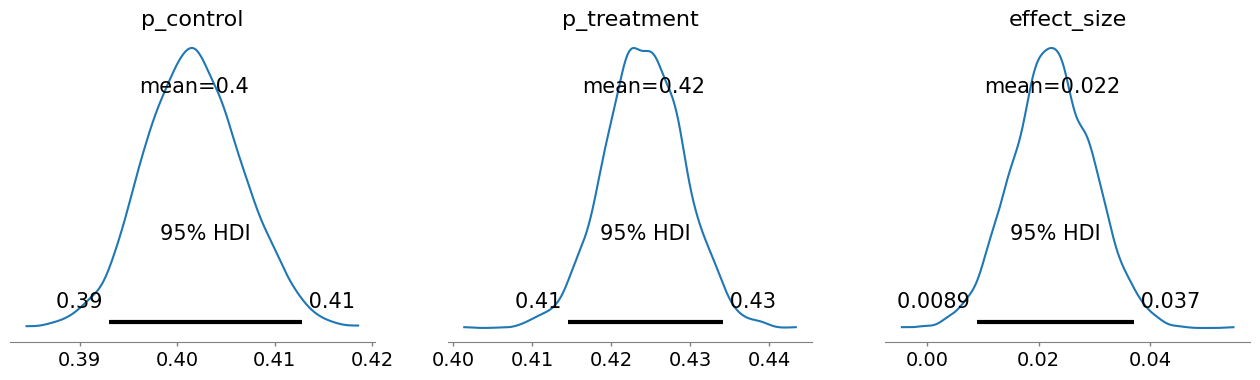

In [48]:
az.plot_posterior(
    data=trace,
    var_names=["p_control", "p_treatment", "effect_size"],
    hdi_prob=0.95,
    figsize=(16, 4),
)

**Observations**
* The posterior is our updated belief about the conversion rate for each group, given the data

* The posterior for `effect_size` gives us a **directly interpretable uncertainty interval**

* The **95% credible interval / HDI** is the range of most plausible effect sizes **given the data and the model**

* That is much closer to the question we actually care about: **how large is the effect, and how sure are we about it?**

* Since the interval is largely above zero, the treatment likely improves conversion.

Let's visualise the two posterior distributions side by side. The separation between them is the evidence that treatment differs from control.

In [49]:
control_posterior = trace.posterior.p_control.values.flatten()  # type: ignore
treatment_posterior = trace.posterior.p_treatment.values.flatten()  # type: ignore
effect_size = trace.posterior.effect_size.values.flatten()  # type: ignore

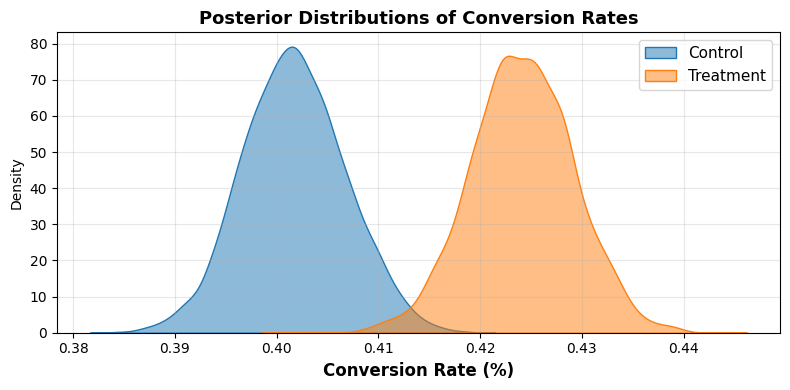

In [50]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.kdeplot(control_posterior, label="Control", fill=True, alpha=0.5, ax=ax)
sns.kdeplot(treatment_posterior, label="Treatment", fill=True, alpha=0.5, ax=ax)
ax.set_xlabel("Conversion Rate (%)", fontsize=12, fontweight="bold")
ax.set_title(
    "Posterior Distributions of Conversion Rates", fontsize=13, fontweight="bold"
)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

And the posterior distribution of the effect size itself. The red dashed line at zero represents "no effect." The more the distribution sits to the right of that line, the stronger the evidence that treatment outperforms control.

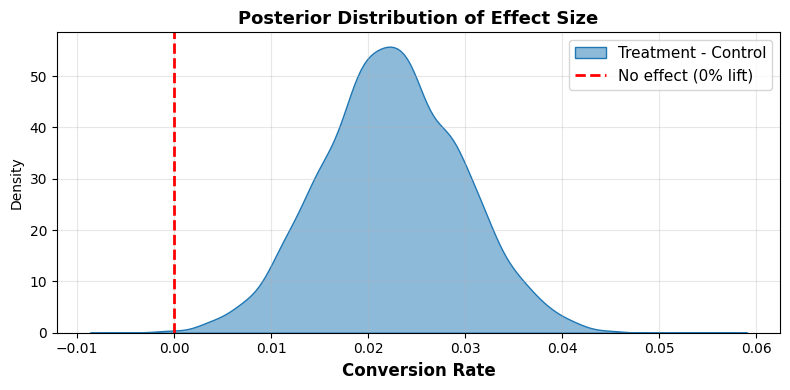

In [51]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.kdeplot(effect_size, label="Treatment - Control", fill=True, alpha=0.5, ax=ax)
ax.axvline(
    0,
    color="red",
    linestyle="--",
    linewidth=2,
    label="No effect (0% lift)",
)
ax.set_xlabel("Conversion Rate", fontsize=12, fontweight="bold")
ax.set_title("Posterior Distribution of Effect Size", fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Finally, the headline number: what fraction of the posterior samples have a positive effect? 

This directly answers the question we actually care about — **"Given the data and our model, what is the probability that the treatment effect is positive?"**

In [52]:
p_positive_effect = (effect_size > 0).mean()
print(
    f"Estimated probability that treatment is better than control: {p_positive_effect:.2%}"
)

Estimated probability that treatment is better than control: 99.90%
